# Part-1 Credit Risk 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
color = sns.color_palette()
import sklearn.metrics as metrics

import warnings
warnings.filterwarnings("ignore")

### Importing the Dataset

In [2]:
data = pd.read_csv('Credit_RiskProject_Data.csv')

In [3]:
data.head()

,Company_Code,Networth Next Year,Capital Employed,Net Working Capital,Current Assets,Total Sales,Retained Earnings,PBDT,PBIT,PBT,...,EPS (Annualised) (Adjusted) (Unit Curr),APATM (%)[Latest],Creditors Velocity (Days),Total Liabilities,Total Equity,Market Value of Equity,total assets,Cost of Production,Current Ratio,Gross Block
0,16974,-8021.60,-1007.24,-1076.34,40.50,0.00,7.60,-926.52,-185.53,-932.99,...,0.0,0.00,0.0,5936.03,419.36,0.00,6355.39,137.67,0.02,474.30
1,21214,-3986.19,4458.20,-1098.88,486.86,2892.73,46.27,-4.32,35.53,-615.25,...,0.0,-87.18,101.0,7410.18,1954.93,1544.39,9365.11,2572.46,0.08,9070.86
2,14852,-3192.58,7714.68,4496.25,9097.64,392.13,9.55,-1086.71,-381.10,-1185.89,...,0.0,-7961.51,558.0,6944.54,53.84,1220.81,6998.38,408.51,1.06,1281.54
3,2439,-3054.51,2353.88,-2612.42,1034.12,1354.39,223.85,-677.57,-336.73,-801.29,...,0.0,-51.58,63.0,2326.05,157.30,194.27,2483.35,1326.99,0.09,1033.69
4,23505,-2967.36,4675.33,1836.23,4685.81,38.72,9.82,-944.42,-710.13,-1006.69,...,0.0,274.79,346.0,5740.90,50.30,113.68,5791.20,186.29,0.50,1084.20


### Fixing Messy Columns 

In [4]:
data.columns = data.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '').str.replace('%', 'perc').str.replace('Adj.','Adjusted')

In [5]:
data = data.rename(columns = {'APATM_perc[Latest]': 'APATM_perc'}, inplace = False)

In [6]:
data.head()

,Company_Code,Networth_Next_Year,Capital_Employed,Net_Working_Capital,Current_Assets,Total_Sales,Retained_Earnings,PBDT,PBIT,PBT,...,EPS_Annualised_Adjustedsted_Unit_Curr,APATM_perc,Creditors_Velocity_Days,Total_Liabilities,Total_Equity,Market_Value_of_Equity,total_assets,Cost_of_Production,Current_Ratio,Gross_Block
0,16974,-8021.60,-1007.24,-1076.34,40.50,0.00,7.60,-926.52,-185.53,-932.99,...,0.0,0.00,0.0,5936.03,419.36,0.00,6355.39,137.67,0.02,474.30
1,21214,-3986.19,4458.20,-1098.88,486.86,2892.73,46.27,-4.32,35.53,-615.25,...,0.0,-87.18,101.0,7410.18,1954.93,1544.39,9365.11,2572.46,0.08,9070.86
2,14852,-3192.58,7714.68,4496.25,9097.64,392.13,9.55,-1086.71,-381.10,-1185.89,...,0.0,-7961.51,558.0,6944.54,53.84,1220.81,6998.38,408.51,1.06,1281.54
3,2439,-3054.51,2353.88,-2612.42,1034.12,1354.39,223.85,-677.57,-336.73,-801.29,...,0.0,-51.58,63.0,2326.05,157.30,194.27,2483.35,1326.99,0.09,1033.69
4,23505,-2967.36,4675.33,1836.23,4685.81,38.72,9.82,-944.42,-710.13,-1006.69,...,0.0,274.79,346.0,5740.90,50.30,113.68,5791.20,186.29,0.50,1084.20


### Checking number of Rows and Columns

In [7]:
data.shape

(3586, 24)

### Checking Datatype   

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3586 entries, 0 to 3585
Data columns (total 24 columns):
Company_Code                             3586 non-null int64
Networth_Next_Year                       3586 non-null float64
Capital_Employed                         3586 non-null float64
Net_Working_Capital                      3586 non-null float64
Current_Assets                           3576 non-null float64
Total_Sales                              3586 non-null float64
Retained_Earnings                        3586 non-null float64
PBDT                                     3586 non-null float64
PBIT                                     3574 non-null float64
PBT                                      3586 non-null float64
PBT_as_perc_of_total_income              3586 non-null float64
PAT                                      3586 non-null float64
CP                                       3586 non-null float64
Book_Value_Adjusted_Unit_Curr            3569 non-null float64
EPS_Annualise

### Checking basic measures 

In [91]:
data.describe()

,LG Train,LG Test,ALTZMAN TRAIN,ALTZMAN TEST
count,2.000000,2.000000,2.000000,2.000000
mean,0.903500,0.910000,0.729000,0.780500
std,0.037477,0.084853,0.001414,0.070004
min,0.877000,0.850000,0.728000,0.731000
25%,0.890250,0.880000,0.728500,0.755750
50%,0.903500,0.910000,0.729000,0.780500
75%,0.916750,0.940000,0.729500,0.805250
max,0.930000,0.970000,0.730000,0.830000


### Checking for Null values  

In [10]:
data.isnull().sum()

Company_Code                              0
Networth_Next_Year                        0
Capital_Employed                          0
Net_Working_Capital                       0
Current_Assets                           10
Total_Sales                               0
Retained_Earnings                         0
PBDT                                      0
PBIT                                     12
PBT                                       0
PBT_as_perc_of_total_income               0
PAT                                       0
CP                                        0
Book_Value_Adjusted_Unit_Curr            17
EPS_Annualised_Adjustedsted_Unit_Curr     4
APATM_perc                                1
Creditors_Velocity_Days                   8
Total_Liabilities                        59
Total_Equity                              0
Market_Value_of_Equity                    0
total_assets                              0
Cost_of_Production                        0
Current_Ratio                   

### Null values have been imputed using Median 

In [11]:
data = data.fillna(data.median())

In [12]:
data.isnull().sum()

Company_Code                             0
Networth_Next_Year                       0
Capital_Employed                         0
Net_Working_Capital                      0
Current_Assets                           0
Total_Sales                              0
Retained_Earnings                        0
PBDT                                     0
PBIT                                     0
PBT                                      0
PBT_as_perc_of_total_income              0
PAT                                      0
CP                                       0
Book_Value_Adjusted_Unit_Curr            0
EPS_Annualised_Adjustedsted_Unit_Curr    0
APATM_perc                               0
Creditors_Velocity_Days                  0
Total_Liabilities                        0
Total_Equity                             0
Market_Value_of_Equity                   0
total_assets                             0
Cost_of_Production                       0
Current_Ratio                            0
Gross_Block

### New Variable Creation

In [13]:
data['Return_on_Total_Asset'] = (data['PBT'] / data['total_assets'])

In [14]:
data['profit_margin'] = (data['PBT'] / data['Total_Sales'])

In [15]:
data['debt_to_equity_ratio'] = (data['Total_Liabilities'] / data['Total_Equity'])

In [16]:
data.head()

,Company_Code,Networth_Next_Year,Capital_Employed,Net_Working_Capital,Current_Assets,Total_Sales,Retained_Earnings,PBDT,PBIT,PBT,...,Total_Liabilities,Total_Equity,Market_Value_of_Equity,total_assets,Cost_of_Production,Current_Ratio,Gross_Block,Return_on_Total_Asset,profit_margin,debt_to_equity_ratio
0,16974,-8021.60,-1007.24,-1076.34,40.50,0.00,7.60,-926.52,-185.53,-932.99,...,5936.03,419.36,0.00,6355.39,137.67,0.02,474.30,-0.146803,-inf,14.154974
1,21214,-3986.19,4458.20,-1098.88,486.86,2892.73,46.27,-4.32,35.53,-615.25,...,7410.18,1954.93,1544.39,9365.11,2572.46,0.08,9070.86,-0.065696,-0.212688,3.790509
2,14852,-3192.58,7714.68,4496.25,9097.64,392.13,9.55,-1086.71,-381.10,-1185.89,...,6944.54,53.84,1220.81,6998.38,408.51,1.06,1281.54,-0.169452,-3.024227,128.984770
3,2439,-3054.51,2353.88,-2612.42,1034.12,1354.39,223.85,-677.57,-336.73,-801.29,...,2326.05,157.30,194.27,2483.35,1326.99,0.09,1033.69,-0.322665,-0.591624,14.787349
4,23505,-2967.36,4675.33,1836.23,4685.81,38.72,9.82,-944.42,-710.13,-1006.69,...,5740.90,50.30,113.68,5791.20,186.29,0.50,1084.20,-0.173831,-25.999225,114.133201


### Checking for duplicates 

In [17]:
data.duplicated().sum()

0

### Outlier Treatment by capping 

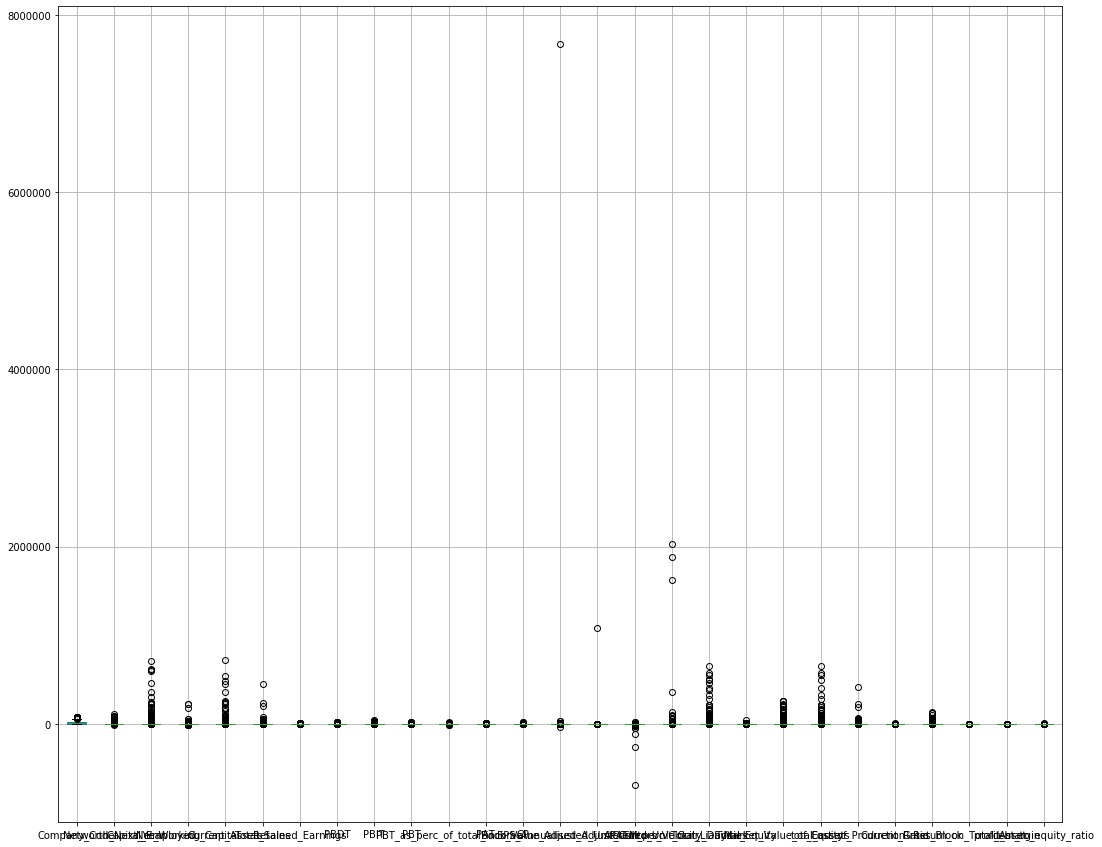

In [18]:
plt.figure(figsize=(18,15))
data.boxplot()

In [19]:
def remove_outlier(col):
    sorted(col)
    Q1,Q3=np.percentile(col,[25,75])
    IQR=Q3-Q1
    lower_range= Q1-(1.5 * IQR)
    upper_range= Q3+(1.5 * IQR)
    return lower_range, upper_range

In [20]:
for column in data:
    lr,ur=remove_outlier(data[column])
    data[column]=np.where(data[column]>ur,ur,data[column])
    data[column]=np.where(data[column]<lr,lr,data[column])

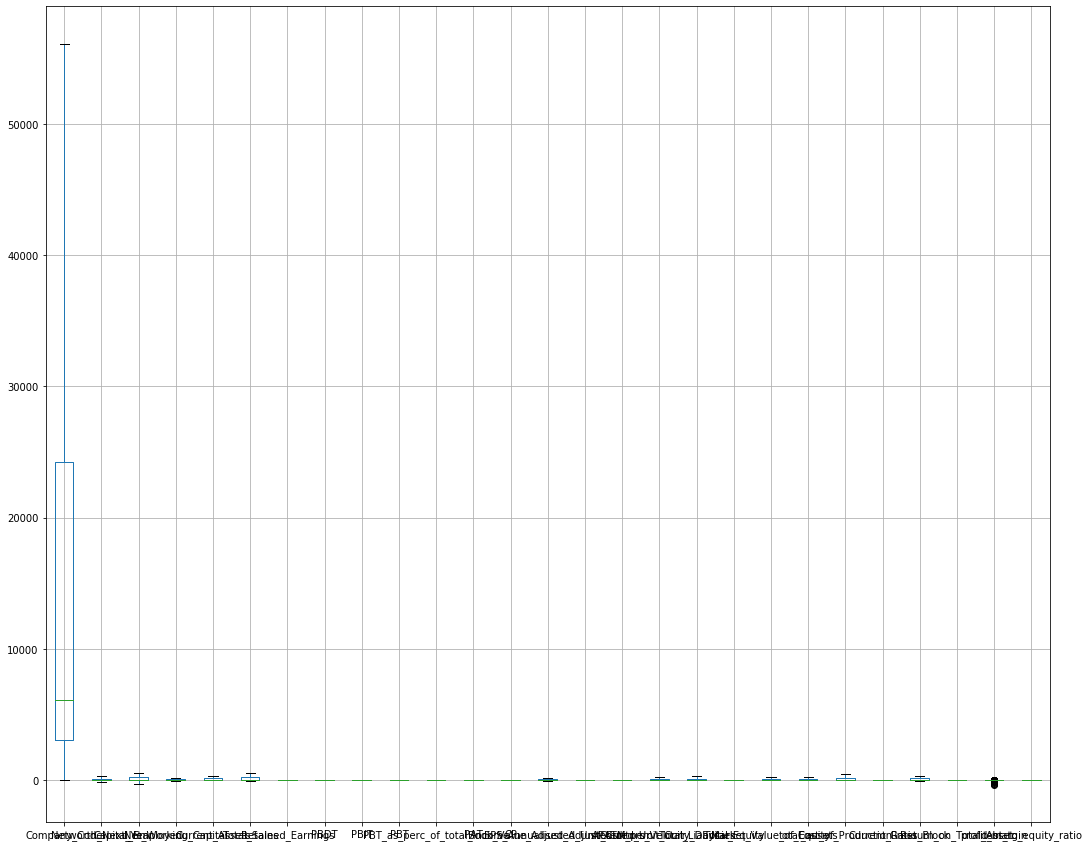

In [21]:
plt.figure(figsize=(18,15))
data.boxplot()

* The dataset contains plenty of null values which have been imputed using Median 
* There is only one integer type while rest of the variables are float type 
* The dataset contains 3586 observations and 24 features 
* There are no duplicates in the dataset 
* Outliers where identified for almost all the features which were treated by capping 

### Target Variable Creation

In [22]:
data['default'] = np.where((data['Networth_Next_Year'] > 0), 0, 1)

In [23]:
data[['default','Networth_Next_Year']].head(10)

,default,Networth_Next_Year
0,1,-175.74125
1,1,-175.74125
2,1,-175.74125
3,1,-175.74125
4,1,-175.74125
5,1,-175.74125
6,1,-175.74125
7,1,-175.74125
8,1,-175.74125
9,1,-175.74125


### Checking Proportion of Default

In [24]:
data['default'].value_counts()

0    3198
1     388
Name: default, dtype: int64

In [25]:
388/(3198+388)

0.10819854991634133

* Target variable default was created by using Networth_next_Year to determine if a company will default or not 
* 10 % of the data shows to be defaulters 

### Univariate Analysis

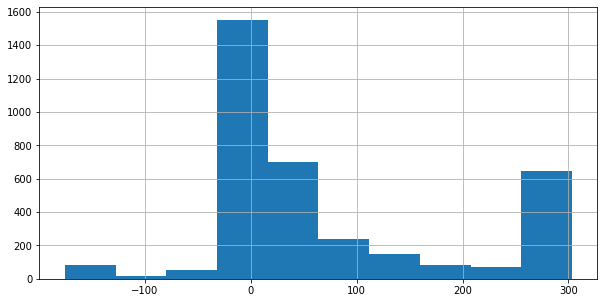

In [26]:
plt.figure(figsize=(10,5))
data.Networth_Next_Year.hist()

 
* Most of the companies are at 0 which suggests they aren't doing well 

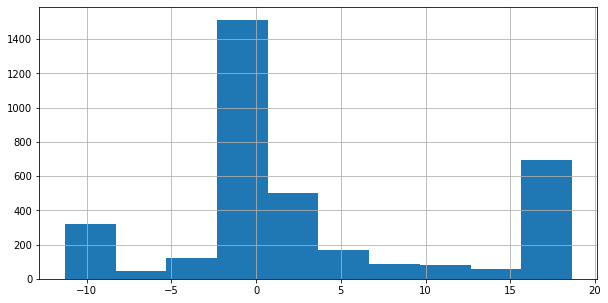

In [27]:
plt.figure(figsize=(10,5))
data.PBT.hist()

* PBT(profit before Tax) is roughly normally distributed 
* similarly most of the companies are making close to 0 profits 

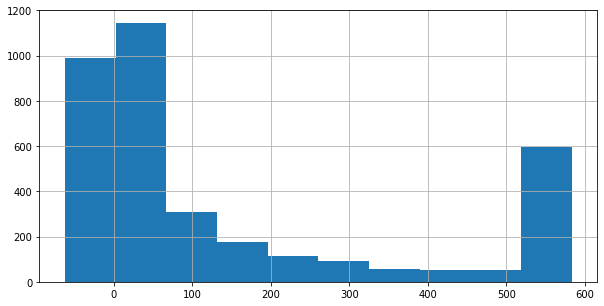

In [28]:
plt.figure(figsize=(10,5))
data.Total_Sales.hist()

* Total Sales is severely skewed to the right 
* It suggests most of the companies are making close to 0 sales while a handful is making good Sales 

### Bi-variate Analysis

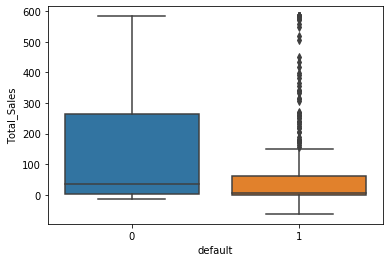

In [29]:
sns.boxplot(data['default'],data['Total_Sales'])

* Companies with high Sales are less likely to Default

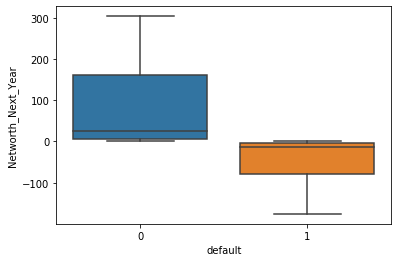

In [30]:
sns.boxplot(data['default'],data['Networth_Next_Year'])

* Companies with positive Networth are not defaulting

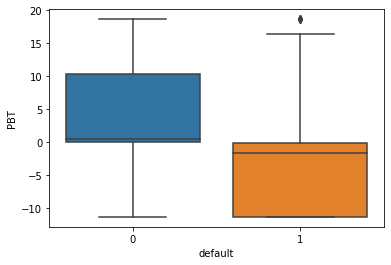

In [31]:
sns.boxplot(data['default'],data['PBT'])

* Companies with negative profits are most likely to Default 

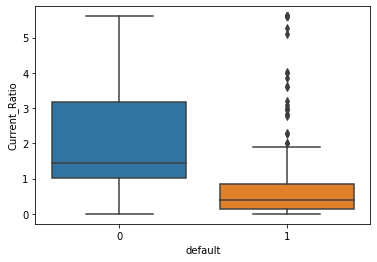

In [32]:
sns.boxplot(data['default'],data['Current_Ratio'])

* Companies with higher Current Ratio are less likely to Default 

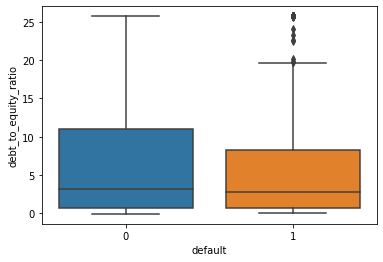

In [33]:
sns.boxplot(data['default'],data['debt_to_equity_ratio'])

* In the case of Debt to Equity ratio it doesn't seem to have a major effect on Default 

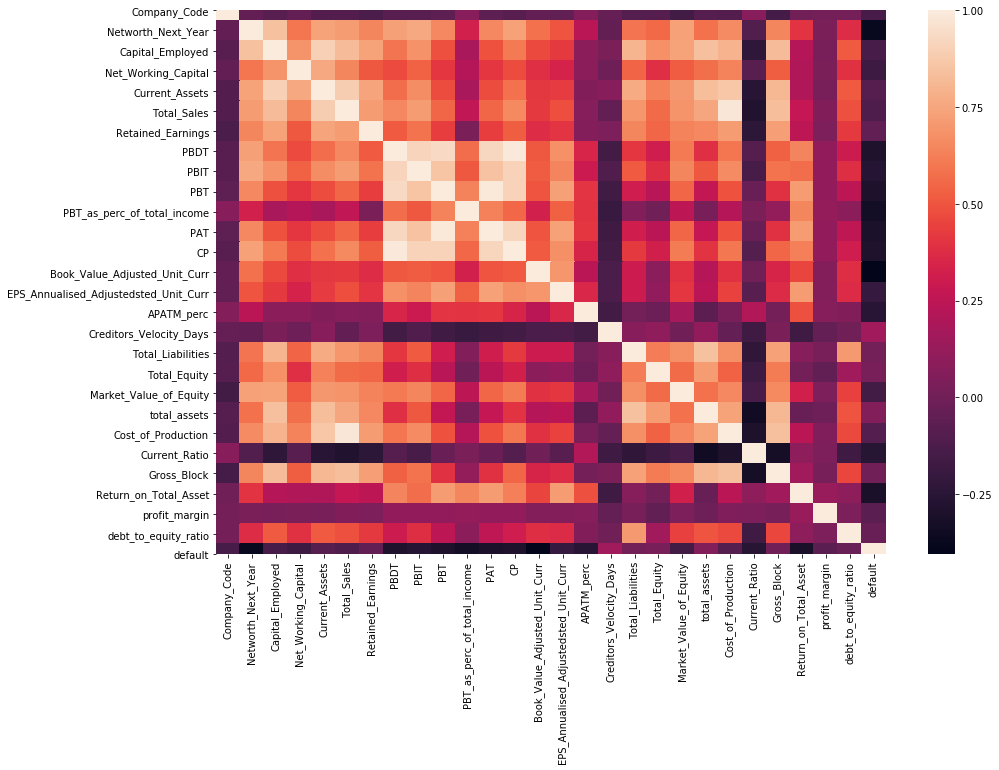

In [34]:
plt.figure(figsize=(15,10))
sns.heatmap(data.corr())

* Most of the Variables are highly Correlated with each other, these variables will be ignored during Model Building to avoid Multi-Colinearity 

### Train-Test Split

In [35]:
X = data.drop('default', axis=1) 
y = data[['default']]

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33 , random_state=42)

* The data has been split into train and test in a 87:33 ratio at a random state of 42 

### Model building

In [37]:
import statsmodels.formula.api as SM

In [38]:
Default_train = pd.concat([X_train,y_train], axis=1)
Default_test = pd.concat([X_test,y_test], axis=1)

In [39]:
Default_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2402 entries, 662 to 3174
Data columns (total 28 columns):
Company_Code                             2402 non-null float64
Networth_Next_Year                       2402 non-null float64
Capital_Employed                         2402 non-null float64
Net_Working_Capital                      2402 non-null float64
Current_Assets                           2402 non-null float64
Total_Sales                              2402 non-null float64
Retained_Earnings                        2402 non-null float64
PBDT                                     2402 non-null float64
PBIT                                     2402 non-null float64
PBT                                      2402 non-null float64
PBT_as_perc_of_total_income              2402 non-null float64
PAT                                      2402 non-null float64
CP                                       2402 non-null float64
Book_Value_Adjusted_Unit_Curr            2402 non-null float64
EPS_Annua

* Due to Feature engineering using Default_SMOTE Dataset the target variable has been concatenated

In [40]:
model_1 = SM.logit(formula = 'default ~ PBT_as_perc_of_total_income + PAT + Book_Value_Adjusted_Unit_Curr + EPS_Annualised_Adjustedsted_Unit_Curr + APATM_perc + Creditors_Velocity_Days + Current_Ratio + Return_on_Total_Asset + debt_to_equity_ratio', data=Default_train).fit()

Optimization terminated successfully.
         Current function value: 0.130591
         Iterations 10


In [41]:
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                 2402
Model:                          Logit   Df Residuals:                     2392
Method:                           MLE   Df Model:                            9
Date:                Sun, 27 Sep 2020   Pseudo R-squ.:                  0.6036
Time:                        10:46:07   Log-Likelihood:                -313.68
converged:                       True   LL-Null:                       -791.34
Covariance Type:            nonrobust   LLR p-value:                7.383e-200
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                -0.6866      0.201     -3.419      0.001      -1.080      -0.293
PBT_as_perc_of_total_income              -0.1353      0.042     -3.190      0.001      -0.218      -0.052
PAT                                      -0.0631      0.040     -1.587      0.113      -0.141       0.015
Book_Value_Adjusted_Unit_Curr            -0.1180      0.011    -11.086      0.000      -0.139      -0.097
EPS_Annualised_Adjustedsted_Unit_Curr     0.1732      0.090      1.923      0.054      -0.003       0.350
APATM_perc                               -0.0522      0.015     -3.458      0.001      -0.082      -0.023
Creditors_Velocity_Days                   0.0002      0.001      0.121      0.904      -0.002       0.003
Current_Ratio                            -0.5603      0.091     -6.142      0.000      -0.739      -0.381
Return_on_Total_Asset                     0.0471      1.459      0.032      0.974      -2.813       2.907
debt_to_equity_ratio                      0.0134      0.016      0.813      0.416      -0.019       0.046
=========================================================================================================

Possibly complete quasi-separation: A fraction 0.26 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

* In the first model P-value of Creditors Velocity days is high and thus will be eliminated 

In [42]:
model_2 = SM.logit(formula = 'default ~ PBT_as_perc_of_total_income + PAT + Book_Value_Adjusted_Unit_Curr + EPS_Annualised_Adjustedsted_Unit_Curr + APATM_perc + Current_Ratio + Return_on_Total_Asset + debt_to_equity_ratio', data=Default_train).fit()

Optimization terminated successfully.
         Current function value: 0.130594
         Iterations 10


In [43]:
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                 2402
Model:                          Logit   Df Residuals:                     2393
Method:                           MLE   Df Model:                            8
Date:                Sun, 27 Sep 2020   Pseudo R-squ.:                  0.6036
Time:                        10:46:07   Log-Likelihood:                -313.69
converged:                       True   LL-Null:                       -791.34
Covariance Type:            nonrobust   LLR p-value:                6.590e-201
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                -0.6750      0.176     -3.829      0.000      -1.021      -0.329
PBT_as_perc_of_total_income              -0.1355      0.042     -3.200      0.001      -0.219      -0.053
PAT                                      -0.0633      0.040     -1.591      0.112      -0.141       0.015
Book_Value_Adjusted_Unit_Curr            -0.1180      0.011    -11.093      0.000      -0.139      -0.097
EPS_Annualised_Adjustedsted_Unit_Curr     0.1738      0.090      1.935      0.053      -0.002       0.350
APATM_perc                               -0.0523      0.015     -3.469      0.001      -0.082      -0.023
Current_Ratio                            -0.5606      0.091     -6.152      0.000      -0.739      -0.382
Return_on_Total_Asset                     0.0424      1.459      0.029      0.977      -2.816       2.901
debt_to_equity_ratio                      0.0134      0.016      0.818      0.413      -0.019       0.046
=========================================================================================================

Possibly complete quasi-separation: A fraction 0.26 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

* Return on Total Asset is also eliminated due to high P-value

In [44]:
model_3 = SM.logit(formula = 'default ~ PBT_as_perc_of_total_income + PAT + Book_Value_Adjusted_Unit_Curr + EPS_Annualised_Adjustedsted_Unit_Curr + APATM_perc + Current_Ratio + debt_to_equity_ratio', data=Default_train).fit()

Optimization terminated successfully.
         Current function value: 0.130595
         Iterations 10


In [45]:
model_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                 2402
Model:                          Logit   Df Residuals:                     2394
Method:                           MLE   Df Model:                            7
Date:                Sun, 27 Sep 2020   Pseudo R-squ.:                  0.6036
Time:                        10:46:07   Log-Likelihood:                -313.69
converged:                       True   LL-Null:                       -791.34
Covariance Type:            nonrobust   LLR p-value:                5.440e-202
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                -0.6757      0.175     -3.866      0.000      -1.018      -0.333
PBT_as_perc_of_total_income              -0.1351      0.039     -3.420      0.001      -0.213      -0.058
PAT                                      -0.0628      0.036     -1.758      0.079      -0.133       0.007
Book_Value_Adjusted_Unit_Curr            -0.1180      0.011    -11.135      0.000      -0.139      -0.097
EPS_Annualised_Adjustedsted_Unit_Curr     0.1745      0.086      2.033      0.042       0.006       0.343
APATM_perc                               -0.0522      0.015     -3.491      0.000      -0.082      -0.023
Current_Ratio                            -0.5604      0.091     -6.167      0.000      -0.739      -0.382
debt_to_equity_ratio                      0.0134      0.016      0.819      0.413      -0.019       0.046
=========================================================================================================

Possibly complete quasi-separation: A fraction 0.26 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

* In this model debt to equity has high P-vlue and thus eliminated 

In [46]:
model_4 = SM.logit(formula = 'default ~ PBT_as_perc_of_total_income + PAT + Book_Value_Adjusted_Unit_Curr + EPS_Annualised_Adjustedsted_Unit_Curr + APATM_perc + Current_Ratio', data=Default_train).fit()

Optimization terminated successfully.
         Current function value: 0.130730
         Iterations 10


In [47]:
model_4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                 2402
Model:                          Logit   Df Residuals:                     2395
Method:                           MLE   Df Model:                            6
Date:                Sun, 27 Sep 2020   Pseudo R-squ.:                  0.6032
Time:                        10:46:07   Log-Likelihood:                -314.01
converged:                       True   LL-Null:                       -791.34
Covariance Type:            nonrobust   LLR p-value:                5.718e-203
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                -0.6368      0.168     -3.792      0.000      -0.966      -0.308
PBT_as_perc_of_total_income              -0.1342      0.039     -3.399      0.001      -0.212      -0.057
PAT                                      -0.0687      0.035     -1.945      0.052      -0.138       0.001
Book_Value_Adjusted_Unit_Curr            -0.1171      0.010    -11.158      0.000      -0.138      -0.097
EPS_Annualised_Adjustedsted_Unit_Curr     0.1893      0.083      2.286      0.022       0.027       0.352
APATM_perc                               -0.0511      0.015     -3.434      0.001      -0.080      -0.022
Current_Ratio                            -0.5601      0.091     -6.154      0.000      -0.738      -0.382
=========================================================================================================

Possibly complete quasi-separation: A fraction 0.26 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

* None of the P-values are high suggesting all features significant deeming this the final model 

In [48]:
coefficients = model_4.params
coefficients

Intercept                               -0.636812
PBT_as_perc_of_total_income             -0.134163
PAT                                     -0.068742
Book_Value_Adjusted_Unit_Curr           -0.117073
EPS_Annualised_Adjustedsted_Unit_Curr    0.189342
APATM_perc                              -0.051138
Current_Ratio                           -0.560099
dtype: float64

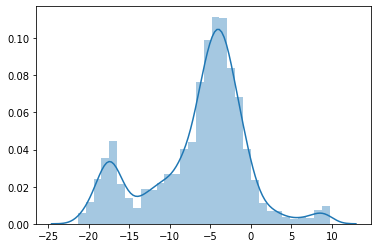

In [49]:
sns.distplot(model_4.fittedvalues);

### Prediction on Train set 

In [50]:
y_predict_train = model_4.predict(X_train)
y_predict_train

662     1.400943e-02
1373    3.912365e-05
3268    4.705553e-08
3246    1.772344e-08
1456    1.650337e-02
            ...     
1130    1.941563e-05
1294    1.991485e-02
860     1.915128e-01
3507    2.917985e-02
3174    7.371727e-04
Length: 2402, dtype: float64

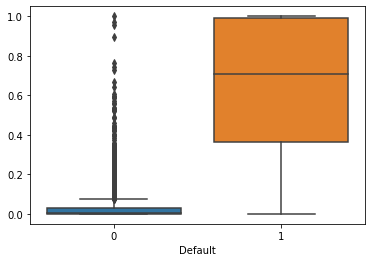

In [51]:
sns.boxplot(x=data['default'],y=y_predict_train)
plt.xlabel('Default');

* optimized cut-off value is taken at 0.08 

In [52]:
y_class_pred=[]
for i in range(0,len(y_predict_train)):
    if np.array(y_predict_train)[i]>0.08:
        a=1
    else:
        a=0
    y_class_pred.append(a)

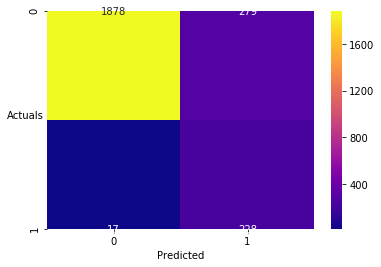

In [53]:
sns.heatmap((metrics.confusion_matrix(y_train,y_class_pred)),annot=True,fmt='.5g'
            ,cmap='plasma');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [54]:
print(metrics.classification_report(y_train,y_class_pred,digits=3))

              precision    recall  f1-score   support

           0      0.991     0.871     0.927      2157
           1      0.450     0.931     0.606       245

    accuracy                          0.877      2402
   macro avg      0.720     0.901     0.767      2402
weighted avg      0.936     0.877     0.894      2402



In [55]:
lg_metrics=metrics.classification_report(y_train, y_class_pred,output_dict=True)
df=pd.DataFrame(lg_metrics).transpose()
lg_train_accuracy=round(df.loc["accuracy"][3],3)
lg_train_recall=round(df.loc["1"][1],2)
print ('lg_train_accuracy ',lg_train_accuracy)
print ('lg_train_recall ',lg_train_recall)

lg_train_accuracy  0.877
lg_train_recall  0.93


* Overall 88% of correct predictions to total predictions were made by the model
* Sensitivity is at 93% 

### Prediction on Test set

In [56]:
y_predict_test = model_4.predict(X_test)
y_predict_test

3163    0.004660
3133    0.001431
937     0.046752
196     0.962808
2852    0.177348
          ...   
2953    0.001817
3116    0.002722
1010    0.000205
1292    0.028639
2130    0.000509
Length: 1184, dtype: float64

In [57]:
y_class_pred=[]
for i in range(0,len(y_predict_test)):
    if np.array(y_predict_test)[i]>0.08:
        a=1
    else:
        a=0
    y_class_pred.append(a)

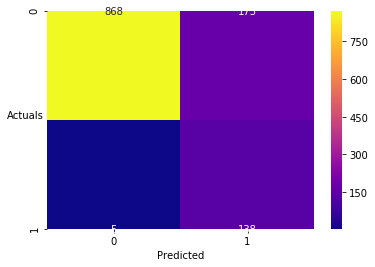

In [58]:
sns.heatmap((metrics.confusion_matrix(y_test,y_class_pred)),annot=True,fmt='.5g'
            ,cmap='plasma');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [59]:
print(metrics.classification_report(y_test,y_class_pred,digits=3))

              precision    recall  f1-score   support

           0      0.994     0.834     0.907      1041
           1      0.444     0.965     0.608       143

    accuracy                          0.850      1184
   macro avg      0.719     0.899     0.757      1184
weighted avg      0.928     0.850     0.871      1184



In [60]:
lg_metrics=metrics.classification_report(y_test, y_class_pred,output_dict=True)
df=pd.DataFrame(lg_metrics).transpose()
lg_test_accuracy=round(df.loc["accuracy"][3],3)
lg_test_recall=round(df.loc["1"][1],2)
print ('lg_test_accuracy ',lg_test_accuracy)
print ('lg_test_recall ',lg_test_recall)

lg_test_accuracy  0.85
lg_test_recall  0.97


* Overall 85% of correct predictions to total predictions were made by the model
* Sensitivity is at 97%

* The model evaluation shows no Overfitting or Underfitting 
* The test model shows good performance 

### Altzman Score on Train set

In [61]:
X_train['Altman_score']=1.2*(X_train.Net_Working_Capital/X_train.total_assets)+1.4*(X_train.Retained_Earnings/X_train.total_assets)+3.3*(X_train.PBIT/X_train.total_assets)+0.6*(X_train.Market_Value_of_Equity/X_train.total_assets)+0.999*(X_train.Total_Sales/X_train.total_assets)
X_train['Altman_score']

662     0.548900
1373    1.962124
3268    4.456841
3246    1.765437
1456    8.053455
          ...   
1130    4.689407
1294    5.651758
860     0.268056
3507    3.658916
3174    2.531099
Name: Altman_score, Length: 2402, dtype: float64

In [62]:
X_train['Altman_score'].describe()

count    2402.000000
mean        9.939614
std        63.127963
min      -232.440000
25%         1.234943
50%         3.561337
75%         5.960382
max      1727.215553
Name: Altman_score, dtype: float64

In [63]:
alt_train_pred=[]
for i in range(0,len(X_train['Altman_score'])):
    if np.array(X_train['Altman_score'])[i]<1.8:
        a=1
    else:
        a=0
    alt_train_pred.append(a)

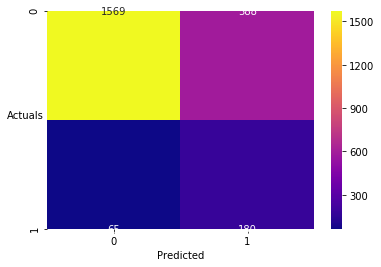

In [64]:
sns.heatmap((metrics.confusion_matrix(y_train['default'],alt_train_pred)),annot=True,fmt='.5g'
            ,cmap='plasma');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [65]:
print(metrics.classification_report(y_train['default'],alt_train_pred,digits=3))

              precision    recall  f1-score   support

           0      0.960     0.727     0.828      2157
           1      0.234     0.735     0.355       245

    accuracy                          0.728      2402
   macro avg      0.597     0.731     0.592      2402
weighted avg      0.886     0.728     0.780      2402



In [66]:
alt_metrics=metrics.classification_report(y_train['default'],alt_train_pred,output_dict=True)
df=pd.DataFrame(alt_metrics).transpose()
alt_train_accuracy=round(df.loc["accuracy"][3],3)
alt_train_recall=round(df.loc["1"][1],2)
print ('alt_train_accuracy ',alt_train_accuracy)
print ('alt_train_recall ',alt_train_recall)

alt_train_accuracy  0.728
alt_train_recall  0.73


* Overall 73% of correct predictions to total predictions were made by the model
* Sensitivity is at 73%

### Altzman Score on test Set 

In [67]:
X_test['Altman_score']=1.2*(X_test.Net_Working_Capital/X_test.total_assets)+1.4*(X_test.Retained_Earnings/X_test.total_assets)+3.3*(X_test.PBIT/X_test.total_assets)+0.6*(X_test.Market_Value_of_Equity/X_test.total_assets)+0.999*(X_test.Total_Sales/X_test.total_assets)
X_test['Altman_score']

3163    4.375994
3133    3.067406
937     0.717634
196     0.692266
2852    4.689848
          ...   
2953    4.342637
3116    4.303154
1010    4.797773
1292    1.132646
2130    5.811340
Name: Altman_score, Length: 1184, dtype: float64

In [68]:
alt_test_pred=[]
for i in range(0,len(X_test['Altman_score'])):
    if np.array(X_test['Altman_score'])[i]<1.8:
        a=1
    else:
        a=0
    alt_test_pred.append(a)

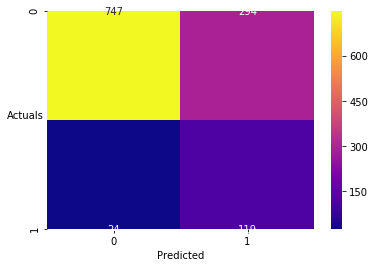

In [69]:
sns.heatmap((metrics.confusion_matrix(y_test['default'],alt_test_pred)),annot=True,fmt='.5g'
            ,cmap='plasma');
plt.xlabel('Predicted');
plt.ylabel('Actuals',rotation=0);

In [70]:
print(metrics.classification_report(y_test['default'],alt_test_pred,digits=3))

              precision    recall  f1-score   support

           0      0.969     0.718     0.825      1041
           1      0.288     0.832     0.428       143

    accuracy                          0.731      1184
   macro avg      0.629     0.775     0.626      1184
weighted avg      0.887     0.731     0.777      1184



In [71]:
alt_metrics=metrics.classification_report(y_test['default'],alt_test_pred,output_dict=True)
df=pd.DataFrame(alt_metrics).transpose()
alt_test_accuracy=round(df.loc["accuracy"][3],3)
alt_test_recall=round(df.loc["1"][1],2)
print ('alt_test_accuracy ',alt_test_accuracy)
print ('alt_test_recall ',alt_test_recall)

alt_test_accuracy  0.731
alt_test_recall  0.83


* Overall 73% of correct predictions to total predictions were made by the model
* Sensitivity is at 83%

### Comparing Regression model with Altzman Score 

In [72]:
index=['Accuracy', 'Recall']
data = pd.DataFrame({'LG Train':[lg_train_accuracy,lg_train_recall],
        'LG Test':[lg_test_accuracy,lg_test_recall],
       'ALTZMAN TRAIN':[alt_train_accuracy,alt_train_recall],
       'ALTZMAN TEST':[alt_test_accuracy,alt_test_recall]},index=index)
round(data,2)

,LG Train,LG Test,ALTZMAN TRAIN,ALTZMAN TEST
Accuracy,0.88,0.85,0.73,0.73
Recall,0.93,0.97,0.73,0.83


* The regression model is clearly best at predicitng compared to the Altzman Score 

# Part-2 Market Risk 

### Importing the Dataset

In [73]:
stock_prices = pd.read_csv('Market+Risk+Dataset.csv')
stock_prices.head()

,Date,Infosys,Indian Hotel,Mahindra & Mahindra,Axis Bank,SAIL,Shree Cement,Sun Pharma,Jindal Steel,Idea Vodafone,Jet Airways
0,31-03-2014,264,69,455,263,68,5543,555,298,83,278
1,07-04-2014,257,68,458,276,70,5728,610,279,84,303
2,14-04-2014,254,68,454,270,68,5649,607,279,83,280
3,21-04-2014,253,68,488,283,68,5692,604,274,83,282
4,28-04-2014,256,65,482,282,63,5582,611,238,79,243


### Fixing Messy Columns

In [74]:
stock_prices.columns = stock_prices.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '').str.replace('.', '')

In [75]:
stock_prices.head()

,Date,Infosys,Indian_Hotel,Mahindra_&_Mahindra,Axis_Bank,SAIL,Shree_Cement,Sun_Pharma,Jindal_Steel,Idea_Vodafone,Jet_Airways
0,31-03-2014,264,69,455,263,68,5543,555,298,83,278
1,07-04-2014,257,68,458,276,70,5728,610,279,84,303
2,14-04-2014,254,68,454,270,68,5649,607,279,83,280
3,21-04-2014,253,68,488,283,68,5692,604,274,83,282
4,28-04-2014,256,65,482,282,63,5582,611,238,79,243


### Checking Shape of Data

In [76]:
stock_prices.shape

(314, 11)

### Checking information about the data 

In [77]:
stock_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 11 columns):
Date                   314 non-null object
Infosys                314 non-null int64
Indian_Hotel           314 non-null int64
Mahindra_&_Mahindra    314 non-null int64
Axis_Bank              314 non-null int64
SAIL                   314 non-null int64
Shree_Cement           314 non-null int64
Sun_Pharma             314 non-null int64
Jindal_Steel           314 non-null int64
Idea_Vodafone          314 non-null int64
Jet_Airways            314 non-null int64
dtypes: int64(10), object(1)
memory usage: 27.1+ KB


### Descriptive Statitstics on data 

In [78]:
stock_prices.describe()

,Infosys,Indian_Hotel,Mahindra_&_Mahindra,Axis_Bank,SAIL,Shree_Cement,Sun_Pharma,Jindal_Steel,Idea_Vodafone,Jet_Airways
count,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000
mean,511.340764,114.560510,636.678344,540.742038,59.095541,14806.410828,633.468153,147.627389,53.713376,372.659236
std,135.952051,22.509732,102.879975,115.835569,15.810493,4288.275085,171.855893,65.879195,31.248985,202.262668
min,234.000000,64.000000,284.000000,263.000000,21.000000,5543.000000,338.000000,53.000000,3.000000,14.000000
25%,424.000000,96.000000,572.000000,470.500000,47.000000,10952.250000,478.500000,88.250000,25.250000,243.250000
50%,466.500000,115.000000,625.000000,528.000000,57.000000,16018.500000,614.000000,142.500000,53.000000,376.000000
75%,630.750000,134.000000,678.000000,605.250000,71.750000,17773.250000,785.000000,182.750000,82.000000,534.000000
max,810.000000,157.000000,956.000000,808.000000,104.000000,24806.000000,1089.000000,338.000000,117.000000,871.000000


### Checking for null values and duplication 

In [79]:
stock_prices.isnull().sum()

Date                   0
Infosys                0
Indian_Hotel           0
Mahindra_&_Mahindra    0
Axis_Bank              0
SAIL                   0
Shree_Cement           0
Sun_Pharma             0
Jindal_Steel           0
Idea_Vodafone          0
Jet_Airways            0
dtype: int64

In [80]:
stock_prices.duplicated().sum()

0

* There are 314 observations and 11 features 
* there are no null or duplicated values in the dataset 
* Except for date every other feature is of integer type 

### Drawing Stock price Charts for Infosys and Jet airways 

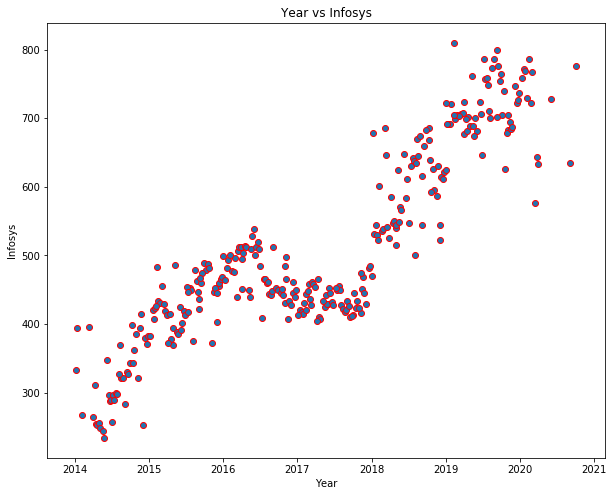

In [81]:
plt.figure(figsize = (10, 8))
stock_prices['dates'] = [pd.to_datetime(d) for d in stock_prices['Date']]
plt.scatter(stock_prices['dates'], stock_prices['Infosys'], edgecolors='r')
plt.xlabel('Year')
plt.ylabel('Infosys')
plt.title('Year vs Infosys')

plt.show()

* Over the years the Stock price of Infosys has increased higher sans a dip in 2017-18 although in 2020 there is a scatter ranging from 600 to 800

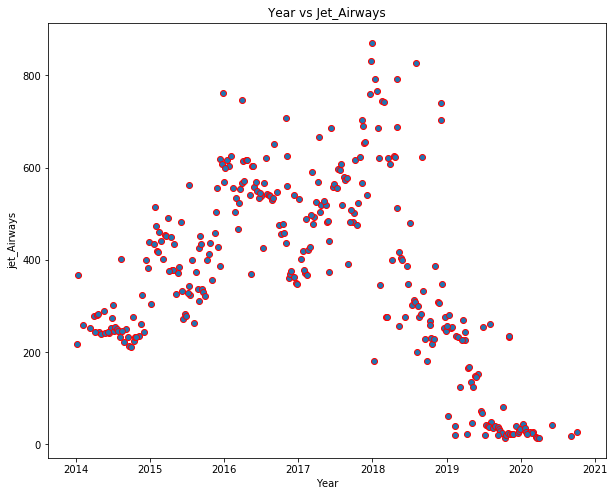

In [82]:
plt.figure(figsize = (10, 8))
stock_prices['dates'] = [pd.to_datetime(d) for d in stock_prices['Date']]
plt.scatter(stock_prices['dates'], stock_prices['Jet_Airways'], edgecolors='r')
plt.xlabel('Year')
plt.ylabel('jet_Airways')
plt.title('Year vs Jet_Airways')

plt.show()

* There is no definite trend in the Stock price of Jet Airways over the years, but from 2019 the price seems to be plummeting rapidly

### Calculating Stock returns 

In [83]:
stock_returns = np.log(stock_prices.drop(['Date','dates'],axis=1)).diff(axis = 0, periods = 1) 

In [84]:
stock_returns.shape

(314, 10)

In [85]:
stock_returns.head()

,Infosys,Indian_Hotel,Mahindra_&_Mahindra,Axis_Bank,SAIL,Shree_Cement,Sun_Pharma,Jindal_Steel,Idea_Vodafone,Jet_Airways
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-0.026873,-0.014599,0.006572,0.048247,0.028988,0.032831,0.094491,-0.065882,0.011976,0.086112
2,-0.011742,0.000000,-0.008772,-0.021979,-0.028988,-0.013888,-0.004930,0.000000,-0.011976,-0.078943
3,-0.003945,0.000000,0.072218,0.047025,0.000000,0.007583,-0.004955,-0.018084,0.000000,0.007117
4,0.011788,-0.045120,-0.012371,-0.003540,-0.076373,-0.019515,0.011523,-0.140857,-0.049393,-0.148846


### Calculating Stock Means and Standard Deviation

In [86]:
stock_means = stock_returns.mean(axis = 0)
stock_means

Infosys                0.002794
Indian_Hotel           0.000266
Mahindra_&_Mahindra   -0.001506
Axis_Bank              0.001167
SAIL                  -0.003463
Shree_Cement           0.003681
Sun_Pharma            -0.001455
Jindal_Steel          -0.004123
Idea_Vodafone         -0.010608
Jet_Airways           -0.009548
dtype: float64

* Shree Cement has the highest Stock return followed by Infosys and Axis Bank 

In [87]:
stock_sd = stock_returns.std(axis = 0)
stock_sd

Infosys                0.035070
Indian_Hotel           0.047131
Mahindra_&_Mahindra    0.040169
Axis_Bank              0.045828
SAIL                   0.062188
Shree_Cement           0.039917
Sun_Pharma             0.045033
Jindal_Steel           0.075108
Idea_Vodafone          0.104315
Jet_Airways            0.097972
dtype: float64

* Infosys has the lowest Risk followed by Shree Cement and Mahindra 

### Plotting Stock Mean Vs Standard Deviation 

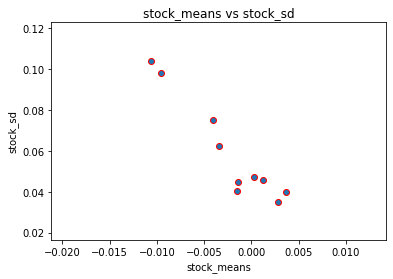

In [88]:
plt.scatter(stock_means, stock_sd, edgecolors='r')
plt.xlabel('stock_means')
plt.ylabel('stock_sd')
plt.title('stock_means vs stock_sd')
plt.show()

* The Scatter Plot suggests higher the return lower the risk